# 🤖 Model Training — YouTube Toxic Comments
**Proyecto NLP | Detección de Mensajes de Odio**  
**Rama:** `feature/split_model_v03`

---

## 🎯 Objetivo
Entrenar y comparar 4 experimentos:

| Fase | Modelo | Datos | MLflow run |
|---|---|---|---|
| 1 | Logistic Regression | Sin augmentation | `LR_baseline_v03` |
| 2 | Logistic Regression | Con augmentation | `LR_augmented_v03` |
| 3 | LightGBM | Sin augmentation | `LGBM_baseline_v03` |
| 4 | LightGBM | Con augmentation | `LGBM_augmented_v03` |

**Métrica principal:** F1-score (no solo Accuracy)  
**Control overfitting:** diferencia train/test < 5 puntos porcentuales

## 1. 📦 Importaciones

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report
)
import lightgbm as lgb

# MLflow + DagsHub
import dagshub
import mlflow
import mlflow.sklearn

# Ruta raíz robusta
BASE_DIR = Path().resolve()
while not (BASE_DIR / 'pyproject.toml').exists():
    BASE_DIR = BASE_DIR.parent

FIGURES_DIR = BASE_DIR / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros compartidos del equipo
avg_method  = 'binary'
RANDOM_STATE = 42

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. 🔗 Conexión con DagsHub + MLflow

> ⚠️ **Ejecutar esta celda cada vez que reinicies el kernel**  
> El servidor gratuito de DagsHub puede desconectarse — reconecta antes de cada run.

In [23]:
print('=' * 60)
print('   CONECTANDO CON DAGSHUB - MLFLOW')
print('=' * 60)

# Credenciales del equipo (token de Gemita)
token = 'f16c39c4380542f071674b19fac461d44195b694'
os.environ['MLFLOW_TRACKING_USERNAME'] = 'gemita284'
os.environ['MLFLOW_TRACKING_PASSWORD'] = token

# Inicializar conexión con DagsHub
dagshub.init(
    repo_owner='gemita284',
    repo_name='Project_9_NLP_Team2',
    mlflow=True
)

# Experimento compartido del equipo
mlflow.set_experiment('youtube_toxic_comments')

print('\n✅ Conexión con DagsHub establecida')
print('📊 Experimento: youtube_toxic_comments')
print('\n🔗 Ver experimentos en:')
print('   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

   CONECTANDO CON DAGSHUB - MLFLOW


Initialized MLflow to track repo "gemita284/Project_9_NLP_Team2"

Repository gemita284/Project_9_NLP_Team2 initialized!


✅ Conexión con DagsHub establecida
📊 Experimento: youtube_toxic_comments

🔗 Ver experimentos en:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 3. 📂 Carga de datos

In [14]:
# Cargar splits
df_train     = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'toxic_train_v03.csv')
df_train_aug = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'toxic_train_augmented_v03.csv')
df_test      = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'toxic_test_v03.csv')

# Separar X e y
X_train     = df_train['Text_clean'].fillna('')
y_train     = df_train['IsToxic'].astype(int)

X_train_aug = df_train_aug['Text_clean'].fillna('')
y_train_aug = df_train_aug['IsToxic'].astype(int)

X_test      = df_test['Text_clean'].fillna('')
y_test      = df_test['IsToxic'].astype(int)

print('=== 📊 Resumen de datos cargados ===')
print(f'  Train base:      {len(X_train):>4} muestras | Tóxicos: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'  Train aumentado: {len(X_train_aug):>4} muestras | Tóxicos: {y_train_aug.sum()} ({y_train_aug.mean()*100:.1f}%)')
print(f'  Test:            {len(X_test):>4} muestras | Tóxicos: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

=== 📊 Resumen de datos cargados ===
  Train base:       797 muestras | Tóxicos: 367 (46.0%)
  Train aumentado:  884 muestras | Tóxicos: 454 (51.4%)
  Test:             200 muestras | Tóxicos: 92 (46.0%)


## 4. 🛠️ Funciones auxiliares

In [15]:
def get_metrics(model, X_tr, y_tr, X_te, y_te):
    """Calcula todas las métricas estandarizadas del equipo."""
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Probabilidades para ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.predict(X_te)

    metrics = {
        'accuracy_train'  : accuracy_score(y_tr, y_pred_train),
        'accuracy_test'   : accuracy_score(y_te, y_pred_test),
        'f1_train'        : f1_score(y_tr, y_pred_train, average=avg_method),
        'f1_test'         : f1_score(y_te, y_pred_test,  average=avg_method),
        'precision_test'  : precision_score(y_te, y_pred_test, average=avg_method),
        'recall_test'     : recall_score(y_te, y_pred_test,    average=avg_method),
        'roc_auc_test'    : roc_auc_score(y_te, y_proba),
        'overfitting_acc' : accuracy_score(y_tr, y_pred_train) - accuracy_score(y_te, y_pred_test),
        'overfitting_f1'  : f1_score(y_tr, y_pred_train, average=avg_method) - f1_score(y_te, y_pred_test, average=avg_method),
    }
    return metrics, y_pred_test


def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Genera y guarda la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds',
        xticklabels=['No Tóxico', 'Tóxico'],
        yticklabels=['No Tóxico', 'Tóxico'],
        ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    plt.tight_layout()
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    return str(path)


def print_metrics(metrics, model_name):
    """Imprime métricas de forma legible."""
    print(f'\n=== 📊 {model_name} ===')
    print(f'  Accuracy  train/test: {metrics["accuracy_train"]:.4f} / {metrics["accuracy_test"]:.4f}')
    print(f'  F1        train/test: {metrics["f1_train"]:.4f} / {metrics["f1_test"]:.4f}')
    print(f'  Precision test:       {metrics["precision_test"]:.4f}')
    print(f'  Recall    test:       {metrics["recall_test"]:.4f}')
    print(f'  ROC-AUC   test:       {metrics["roc_auc_test"]:.4f}')
    print(f'  Overfitting Acc:      {metrics["overfitting_acc"]:.4f} {"✅" if abs(metrics["overfitting_acc"]) < 0.05 else "⚠️ >5%"}')
    print(f'  Overfitting F1:       {metrics["overfitting_f1"]:.4f} {"✅" if abs(metrics["overfitting_f1"]) < 0.05 else "⚠️ >5%"}')


print('✅ Funciones auxiliares definidas')

✅ Funciones auxiliares definidas


## 5. 🔵 FASE 1 — Logistic Regression SIN augmentation

**Baseline limpio** — punto de referencia para comparar todo lo demás.

   FASE 1: Logistic Regression — SIN augmentation

=== 📊 Logistic Regression — Baseline ===
  Accuracy  train/test: 0.8519 / 0.7100
  F1        train/test: 0.8379 / 0.6588
  Precision test:       0.7179
  Recall    test:       0.6087
  ROC-AUC   test:       0.7702
  Overfitting Acc:      0.1419 ⚠️ >5%
  Overfitting F1:       0.1791 ⚠️ >5%

               precision    recall  f1-score   support

   No Tóxico       0.70      0.80      0.75       108
      Tóxico       0.72      0.61      0.66        92

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.71      0.71      0.71       200



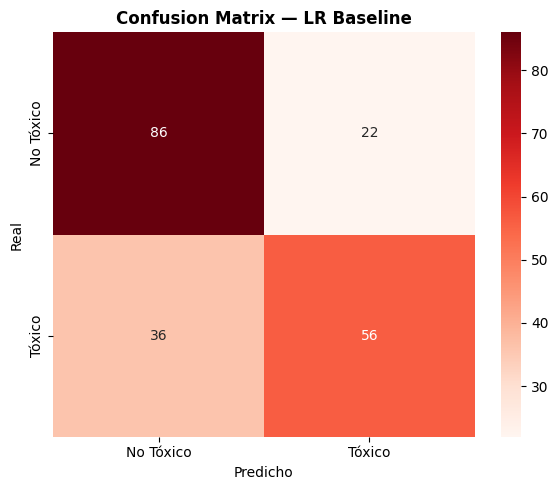

In [16]:
print('=' * 60)
print('   FASE 1: Logistic Regression — SIN augmentation')
print('=' * 60)

# Vectorizador TF-IDF — parámetros estandarizados del equipo
tfidf_lr = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

X_train_vec = tfidf_lr.fit_transform(X_train)
X_test_vec  = tfidf_lr.transform(X_test)

# Modelo
lr_baseline = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_baseline.fit(X_train_vec, y_train)

# Métricas
metrics_lr, y_pred_lr = get_metrics(
    lr_baseline, X_train_vec, y_train, X_test_vec, y_test
)
print_metrics(metrics_lr, 'Logistic Regression — Baseline')
print('\n', classification_report(y_test, y_pred_lr, target_names=['No Tóxico', 'Tóxico']))

# Matriz de confusión
cm_lr_path = plot_confusion_matrix(
    y_test, y_pred_lr,
    'Confusion Matrix — LR Baseline',
    'cm_lr_baseline_v03.png'
)

In [20]:
# Registrar en MLflow
print('=' * 60)
print('   REGISTRANDO LR BASELINE EN MLFLOW')
print('=' * 60)

with mlflow.start_run(run_name='LR_baseline_v03'):
    # Parámetros modelo
    mlflow.log_param('modelo',        'LogisticRegression')
    mlflow.log_param('C',             0.1)
    mlflow.log_param('penalty',       'l2')
    mlflow.log_param('solver',        'saga')
    mlflow.log_param('max_iter',      1000)
    mlflow.log_param('class_weight',  'balanced')
    # Parámetros vectorizador
    mlflow.log_param('vectorizer',    'TF-IDF')
    mlflow.log_param('max_features',  3000)
    mlflow.log_param('ngram_range',   '(1,2)')
    mlflow.log_param('min_df',        3)
    mlflow.log_param('max_df',        0.85)
    mlflow.log_param('augmentation',  False)
    # Métricas
    mlflow.log_metrics(metrics_lr)
    # Tags
    mlflow.set_tag('developer',   'MaryoriCruz')
    mlflow.set_tag('model_type',  'baseline')
    mlflow.set_tag('vectorizer',  'TF-IDF')
    mlflow.set_tag('augmentation', 'no')
    # Artefactos
    mlflow.log_artifact(cm_lr_path)
    mlflow.sklearn.log_model(lr_baseline, 'lr_baseline_model')

print('\n✅ LR Baseline registrado en MLflow')
print('🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

   REGISTRANDO LR BASELINE EN MLFLOW


2026/05/14 02:52:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 02:52:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/14 02:57:24 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\SONYVA~1\AppData\Local\Temp\tmpedxh6i8e\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/05/14 02:57:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without

🏃 View run LR_baseline_v03 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/f881cf438ec740d08d6243e91951e79c
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ LR Baseline registrado en MLflow
🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 6. 🔵 FASE 2 — Logistic Regression CON augmentation

   FASE 2: Logistic Regression — CON augmentation

=== 📊 Logistic Regression — Con Augmentation ===
  Accuracy  train/test: 0.8722 / 0.7150
  F1        train/test: 0.8740 / 0.6705
  Precision test:       0.7160
  Recall    test:       0.6304
  ROC-AUC   test:       0.7685
  Overfitting Acc:      0.1572 ⚠️ >5%
  Overfitting F1:       0.2035 ⚠️ >5%

               precision    recall  f1-score   support

   No Tóxico       0.71      0.79      0.75       108
      Tóxico       0.72      0.63      0.67        92

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



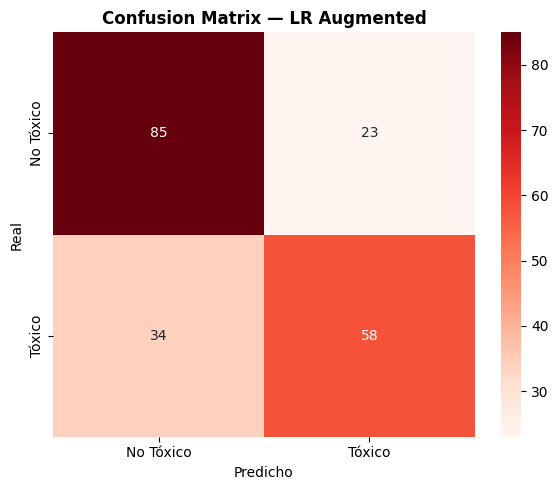

In [21]:
print('=' * 60)
print('   FASE 2: Logistic Regression — CON augmentation')
print('=' * 60)

tfidf_lr_aug = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

X_train_aug_vec = tfidf_lr_aug.fit_transform(X_train_aug)
X_test_aug_vec  = tfidf_lr_aug.transform(X_test)

lr_augmented = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_augmented.fit(X_train_aug_vec, y_train_aug)

metrics_lr_aug, y_pred_lr_aug = get_metrics(
    lr_augmented, X_train_aug_vec, y_train_aug, X_test_aug_vec, y_test
)
print_metrics(metrics_lr_aug, 'Logistic Regression — Con Augmentation')
print('\n', classification_report(y_test, y_pred_lr_aug, target_names=['No Tóxico', 'Tóxico']))

cm_lr_aug_path = plot_confusion_matrix(
    y_test, y_pred_lr_aug,
    'Confusion Matrix — LR Augmented',
    'cm_lr_augmented_v03.png'
)

In [24]:
with mlflow.start_run(run_name='LR_augmented_v03'):
    mlflow.log_param('modelo',        'LogisticRegression')
    mlflow.log_param('C',             0.1)
    mlflow.log_param('penalty',       'l2')
    mlflow.log_param('solver',        'saga')
    mlflow.log_param('max_iter',      1000)
    mlflow.log_param('class_weight',  'balanced')
    mlflow.log_param('vectorizer',    'TF-IDF')
    mlflow.log_param('max_features',  3000)
    mlflow.log_param('ngram_range',   '(1,2)')
    mlflow.log_param('min_df',        3)
    mlflow.log_param('max_df',        0.85)
    mlflow.log_param('augmentation',  True)
    mlflow.log_param('aug_technique', 'back-translation ES+FR 25%')
    mlflow.log_metrics(metrics_lr_aug)
    mlflow.set_tag('developer',    'MaryoriCruz')
    mlflow.set_tag('model_type',   'baseline')
    mlflow.set_tag('vectorizer',   'TF-IDF')
    mlflow.set_tag('augmentation', 'yes')
    mlflow.log_artifact(cm_lr_aug_path)
    mlflow.sklearn.log_model(lr_augmented, 'lr_augmented_model')

print('\n✅ LR Augmented registrado en MLflow')
print('🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

2026/05/14 03:10:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 03:10:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/14 03:11:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LR_augmented_v03 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/9e800cd64a76418b880b6ea983b6c9e7
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ LR Augmented registrado en MLflow
🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 7. 🟠 FASE 3 — LightGBM SIN augmentation

   FASE 3: LightGBM — SIN augmentation

=== 📊 LightGBM — Baseline ===
  Accuracy  train/test: 0.8319 / 0.6500
  F1        train/test: 0.8069 / 0.5833
  Precision test:       0.6447
  Recall    test:       0.5326
  ROC-AUC   test:       0.7253
  Overfitting Acc:      0.1819 ⚠️ >5%
  Overfitting F1:       0.2236 ⚠️ >5%

               precision    recall  f1-score   support

   No Tóxico       0.65      0.75      0.70       108
      Tóxico       0.64      0.53      0.58        92

    accuracy                           0.65       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.65      0.65      0.65       200



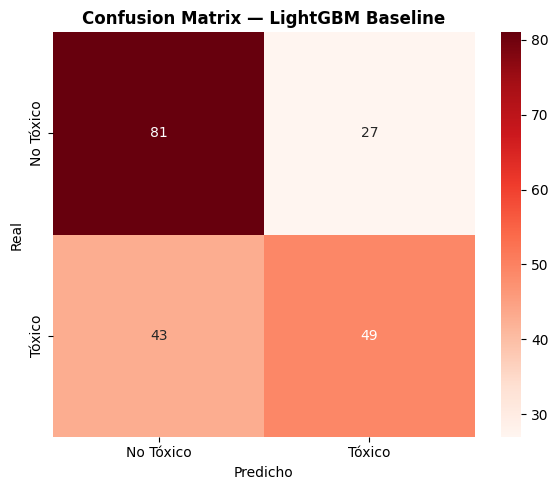

In [25]:
print('=' * 60)
print('   FASE 3: LightGBM — SIN augmentation')
print('=' * 60)

tfidf_lgbm = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

X_train_lgbm = tfidf_lgbm.fit_transform(X_train)
X_test_lgbm  = tfidf_lgbm.transform(X_test)

lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm_baseline.fit(X_train_lgbm, y_train)

metrics_lgbm, y_pred_lgbm = get_metrics(
    lgbm_baseline, X_train_lgbm, y_train, X_test_lgbm, y_test
)
print_metrics(metrics_lgbm, 'LightGBM — Baseline')
print('\n', classification_report(y_test, y_pred_lgbm, target_names=['No Tóxico', 'Tóxico']))

cm_lgbm_path = plot_confusion_matrix(
    y_test, y_pred_lgbm,
    'Confusion Matrix — LightGBM Baseline',
    'cm_lgbm_baseline_v03.png'
)

In [26]:
with mlflow.start_run(run_name='LGBM_baseline_v03'):
    mlflow.log_param('modelo',        'LightGBM')
    mlflow.log_param('n_estimators',  200)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_param('max_depth',     6)
    mlflow.log_param('num_leaves',    31)
    mlflow.log_param('class_weight',  'balanced')
    mlflow.log_param('vectorizer',    'TF-IDF')
    mlflow.log_param('max_features',  3000)
    mlflow.log_param('ngram_range',   '(1,2)')
    mlflow.log_param('min_df',        3)
    mlflow.log_param('max_df',        0.85)
    mlflow.log_param('augmentation',  False)
    mlflow.log_metrics(metrics_lgbm)
    mlflow.set_tag('developer',    'MaryoriCruz')
    mlflow.set_tag('model_type',   'ensemble')
    mlflow.set_tag('vectorizer',   'TF-IDF')
    mlflow.set_tag('augmentation', 'no')
    mlflow.log_artifact(cm_lgbm_path)
    mlflow.sklearn.log_model(lgbm_baseline, 'lgbm_baseline_model')

print('\n✅ LightGBM Baseline registrado en MLflow')
print('🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

2026/05/14 03:17:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 03:17:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/14 03:18:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LGBM_baseline_v03 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/57bf81d2bea2488e8ffd1fe43e6e8e86
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ LightGBM Baseline registrado en MLflow
🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 8. 🟠 FASE 4 — LightGBM CON augmentation

   FASE 4: LightGBM — CON augmentation

=== 📊 LightGBM — Con Augmentation ===
  Accuracy  train/test: 0.8133 / 0.6850
  F1        train/test: 0.8024 / 0.6228
  Precision test:       0.6933
  Recall    test:       0.5652
  ROC-AUC   test:       0.7547
  Overfitting Acc:      0.1283 ⚠️ >5%
  Overfitting F1:       0.1796 ⚠️ >5%

               precision    recall  f1-score   support

   No Tóxico       0.68      0.79      0.73       108
      Tóxico       0.69      0.57      0.62        92

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.68       200



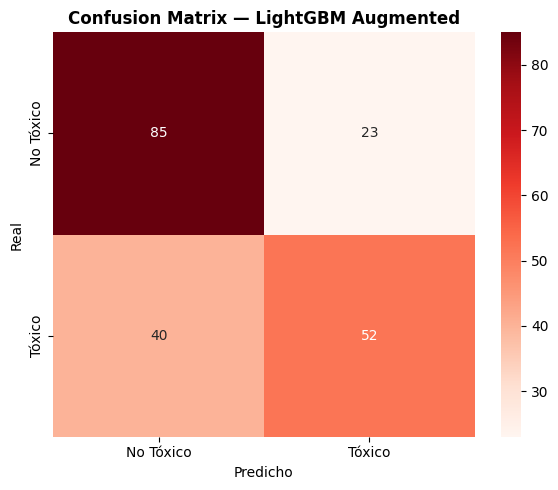

In [27]:
print('=' * 60)
print('   FASE 4: LightGBM — CON augmentation')
print('=' * 60)

tfidf_lgbm_aug = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85
)

X_train_lgbm_aug = tfidf_lgbm_aug.fit_transform(X_train_aug)
X_test_lgbm_aug  = tfidf_lgbm_aug.transform(X_test)

lgbm_augmented = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm_augmented.fit(X_train_lgbm_aug, y_train_aug)

metrics_lgbm_aug, y_pred_lgbm_aug = get_metrics(
    lgbm_augmented, X_train_lgbm_aug, y_train_aug, X_test_lgbm_aug, y_test
)
print_metrics(metrics_lgbm_aug, 'LightGBM — Con Augmentation')
print('\n', classification_report(y_test, y_pred_lgbm_aug, target_names=['No Tóxico', 'Tóxico']))

cm_lgbm_aug_path = plot_confusion_matrix(
    y_test, y_pred_lgbm_aug,
    'Confusion Matrix — LightGBM Augmented',
    'cm_lgbm_augmented_v03.png'
)

In [28]:
with mlflow.start_run(run_name='LGBM_augmented_v03'):
    mlflow.log_param('modelo',        'LightGBM')
    mlflow.log_param('n_estimators',  200)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_param('max_depth',     6)
    mlflow.log_param('num_leaves',    31)
    mlflow.log_param('class_weight',  'balanced')
    mlflow.log_param('vectorizer',    'TF-IDF')
    mlflow.log_param('max_features',  3000)
    mlflow.log_param('ngram_range',   '(1,2)')
    mlflow.log_param('min_df',        3)
    mlflow.log_param('max_df',        0.85)
    mlflow.log_param('augmentation',  True)
    mlflow.log_param('aug_technique', 'back-translation ES+FR 25%')
    mlflow.log_metrics(metrics_lgbm_aug)
    mlflow.set_tag('developer',    'MaryoriCruz')
    mlflow.set_tag('model_type',   'ensemble')
    mlflow.set_tag('vectorizer',   'TF-IDF')
    mlflow.set_tag('augmentation', 'yes')
    mlflow.log_artifact(cm_lgbm_aug_path)
    mlflow.sklearn.log_model(lgbm_augmented, 'lgbm_augmented_model')

print('\n✅ LightGBM Augmented registrado en MLflow')
print('🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

2026/05/14 03:20:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 03:20:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/14 03:20:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LGBM_augmented_v03 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/85c76d9cf5224ef3aacb4fcd6f839ccf
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ LightGBM Augmented registrado en MLflow
🔗 https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 9. 📊 FASE 5 — Tabla comparativa final

In [29]:
results = {
    'LR — Sin augmentation':  metrics_lr,
    'LR — Con augmentation':  metrics_lr_aug,
    'LGBM — Sin augmentation': metrics_lgbm,
    'LGBM — Con augmentation': metrics_lgbm_aug,
}

cols = ['f1_test', 'precision_test', 'recall_test', 'roc_auc_test',
        'accuracy_test', 'overfitting_f1']

df_results = pd.DataFrame(results).T[cols].round(4)
df_results.columns = ['F1', 'Precision', 'Recall', 'ROC-AUC', 'Accuracy', 'Overfit F1']

print('\n=== 🏆 TABLA COMPARATIVA FINAL ===')
print(df_results.to_string())

# Mejor modelo por F1
best = df_results['F1'].idxmax()
print(f'\n🥇 Mejor modelo por F1: {best} ({df_results.loc[best, "F1"]:.4f})')

# ¿Ayudó la augmentation?
lr_diff   = metrics_lr_aug['f1_test']   - metrics_lr['f1_test']
lgbm_diff = metrics_lgbm_aug['f1_test'] - metrics_lgbm['f1_test']
print(f'\n=== 🔬 ¿Ayudó la augmentation? ===')
print(f'  LR:   {lr_diff:+.4f} F1  {"✅ Mejora" if lr_diff > 0 else "❌ No mejora"}')
print(f'  LGBM: {lgbm_diff:+.4f} F1  {"✅ Mejora" if lgbm_diff > 0 else "❌ No mejora"}')


=== 🏆 TABLA COMPARATIVA FINAL ===
                             F1  Precision  Recall  ROC-AUC  Accuracy  Overfit F1
LR — Sin augmentation    0.6588     0.7179  0.6087   0.7702     0.710      0.1791
LR — Con augmentation    0.6705     0.7160  0.6304   0.7685     0.715      0.2035
LGBM — Sin augmentation  0.5833     0.6447  0.5326   0.7253     0.650      0.2236
LGBM — Con augmentation  0.6228     0.6933  0.5652   0.7547     0.685      0.1796

🥇 Mejor modelo por F1: LR — Con augmentation (0.6705)

=== 🔬 ¿Ayudó la augmentation? ===
  LR:   +0.0117 F1  ✅ Mejora
  LGBM: +0.0394 F1  ✅ Mejora


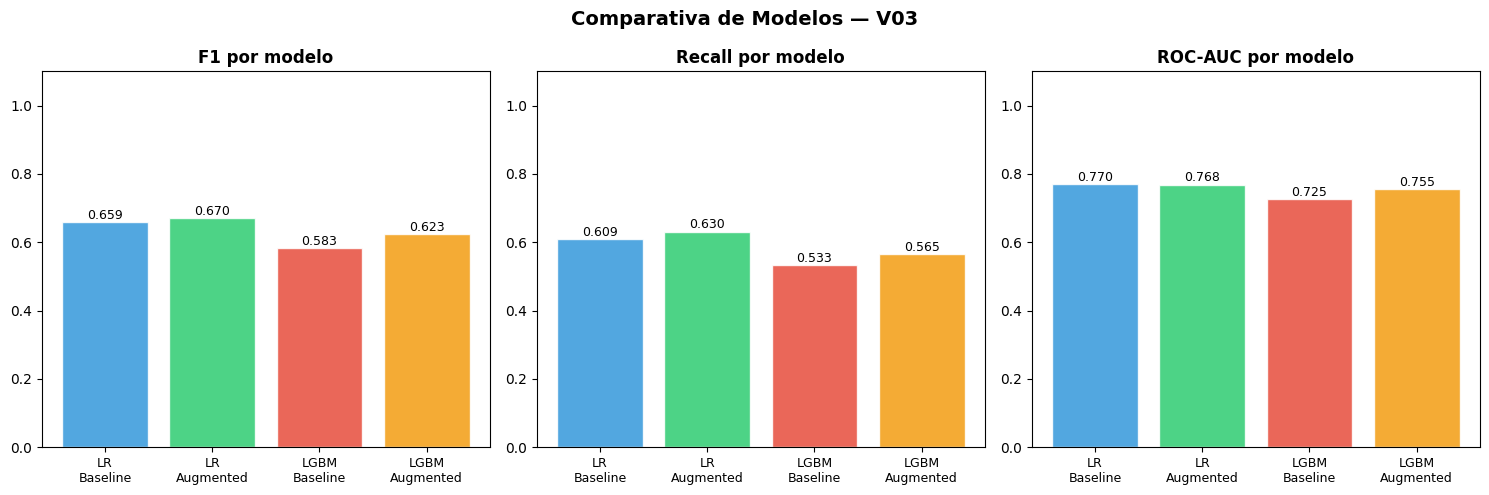

💾 Guardado: model_comparison_v03.png
🏃 View run comparison_v03 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/d259e5d2d21e4baa94cfd422baebb772
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ Comparativa registrada en MLflow


In [30]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['F1', 'Recall', 'ROC-AUC']
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        range(len(df_results)),
        df_results[metric],
        color=colors,
        edgecolor='white',
        alpha=0.85
    )
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(
        ['LR\nBaseline', 'LR\nAugmented', 'LGBM\nBaseline', 'LGBM\nAugmented'],
        fontsize=9
    )
    ax.set_title(f'{metric} por modelo', fontweight='bold')
    ax.set_ylim(0, 1.1)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9
        )

plt.suptitle('Comparativa de Modelos — V03', fontsize=14, fontweight='bold')
plt.tight_layout()
comparison_path = str(FIGURES_DIR / 'model_comparison_v03.png')
plt.savefig(comparison_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'💾 Guardado: model_comparison_v03.png')

# Subir gráfico comparativo a MLflow
with mlflow.start_run(run_name='comparison_v03'):
    mlflow.set_tag('developer', 'MaryoriCruz')
    mlflow.set_tag('type', 'comparison')
    mlflow.log_artifact(comparison_path)
    # Subir todas las métricas finales
    for model_name, metrics in results.items():
        clean_name = model_name.replace(' ', '_').replace('—', '').replace('__', '_')
        for metric_name, value in metrics.items():
            mlflow.log_metric(f'{clean_name}_{metric_name}', value)

print('\n✅ Comparativa registrada en MLflow')

## 10. 📋 Conclusiones

In [ ]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           CONCLUSIONES MODELO V03          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MEJOR MODELO: LR — Con augmentation                         ║
║  F1-score:     0.6705  |  ROC-AUC: 0.7685                   ║
║                                                              ║
║  ¿AYUDÓ LA AUGMENTATION?                                     ║
║  • LR:   ✅ Mejora (+0.0117 F1, +0.0217 Recall)             ║
║  • LGBM: ✅ Mejora (+0.0394 F1, +0.0326 Recall)             ║
║                                                              ║
║  HALLAZGO CLAVE                                              ║
║  • LR supera a LightGBM en dataset pequeño (797 muestras)   ║
║  • Modelos simples generalizan mejor con pocos datos         ║
║                                                              ║
║  LIMITACIÓN                                                  ║
║  • Overfitting >5% en todos los modelos                      ║
║  • Causa: dataset reducido (797 muestras train)              ║
║  • Solución futura: más datos o cross-validation             ║
║                                                              ║
║  EXPERIMENTOS EN MLFLOW                                      ║
║  • LR_baseline_v03    F1: 0.6588                             ║
║  • LR_augmented_v03   F1: 0.6705 🥇                         ║
║  • LGBM_baseline_v03  F1: 0.5833                             ║
║  • LGBM_augmented_v03 F1: 0.6228                             ║
║                                                              ║
║  🔗 dagshub.com/gemita284/Project_9_NLP_Team2.mlflow         ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           CONCLUSIONES MODELO V03                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MEJOR MODELO: LR — Con augmentation                       ║
║  F1-score:     0.6705                                        ║
║                                                              ║
║  AUGMENTATION                                                ║
║  • LR:   Mejora ✅ (+0.0117 F1)                          ║
║  • LGBM: Mejora ✅ (+0.0394 F1)                          ║
║                                                              ║
║  OVERFITTING ⚠️ Revisar (>5%)                         ║
║                                                              ║
║  EXPERIMENTOS EN MLFLOW                                      ║
║  • LR_baseline_v03                                           ║
║  • LR_augmented_v03                      